In [3]:
!pip install matplotlib 


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression


In [6]:
df = pd.read_csv('data_galton.csv', header='infer')
df.head()


,child,parent
0,61.7,70.5
1,61.7,68.5
2,61.7,65.5
3,61.7,64.5
4,61.7,64.0


In [7]:

table = pd.crosstab(df.parent,df.child)
table 

child,61.7,62.2,63.2,64.2,65.2,66.2,67.2,68.2,69.2,70.2,71.2,72.2,73.2,73.7
parent,,,,,,,,,,,,,,
64.0,1,0,2,4,1,2,2,1,1,0,0,0,0,0
64.5,1,1,4,4,1,5,5,0,2,0,0,0,0,0
65.5,1,0,9,5,7,11,11,7,7,5,2,1,0,0
66.5,0,3,3,5,2,17,17,14,13,4,0,0,0,0
67.5,0,3,5,14,15,36,38,28,38,19,11,4,0,0
68.5,1,0,7,11,16,25,31,34,48,21,18,4,3,0
69.5,0,0,1,16,4,17,27,20,33,25,20,11,4,5
70.5,1,0,1,0,1,1,3,12,18,14,7,4,3,3
71.5,0,0,0,0,1,3,4,3,5,10,4,9,2,2


In [8]:
nrows = table.shape[0] 
nrows = table.shape[1]
childHeight = list(table.columns)
parentHeight = list(table.index)
combo =[(x,y,table.loc[x,y])
        for x in parentHeight
        for y in childHeight]
combo = pd.DataFrame(combo , columns =['x','y','freq'])

combo

,x,y,freq
0,64.0,61.7,1
1,64.0,62.2,0
2,64.0,63.2,2
3,64.0,64.2,4
4,64.0,65.2,1
...,...,...,...
149,73.0,70.2,0
150,73.0,71.2,0
151,73.0,72.2,1
152,73.0,73.2,3


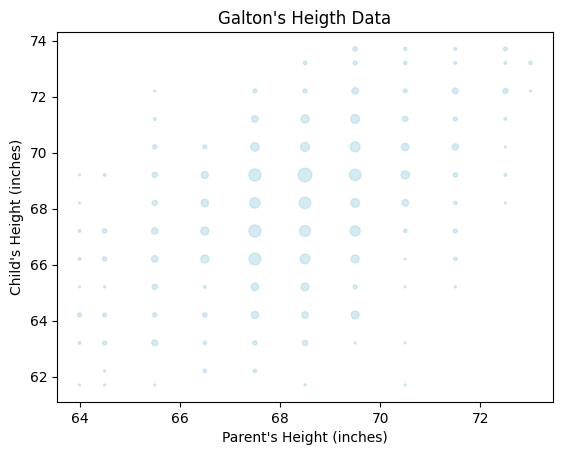

In [9]:
plt.scatter(combo.x, combo.y,s=combo.freq*2, c='lightblue', alpha=0.5)
plt.xlabel("Parent's Height (inches)")
plt.ylabel("Child's Height (inches)")
plt.title("Galton's Heigth Data")
plt.show()

In [8]:
lm =LinearRegression(fit_intercept = True)
lm.fit(df[['parent']], df[['child']])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
print (lm.intercept_,lm.coef_)

[23.94153018] [[0.64629058]]


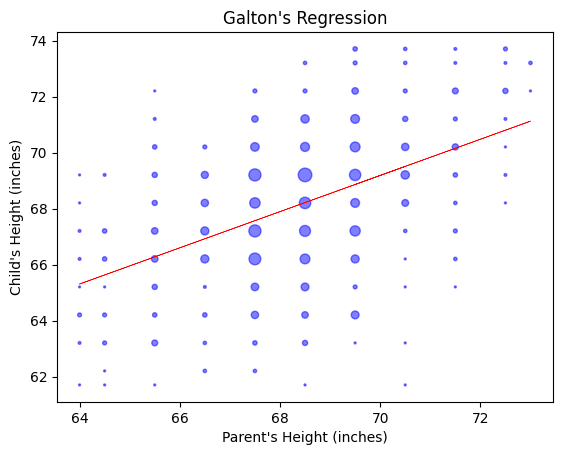

In [ ]:
predY=lm.predict(df[['parent']])
plt.plot(df.parent.values,predY,c='red',linestyle='-',linewidth=0.5)
plt.scatter(combo.x,combo.y,c='blue',alpha=0.5)
plt.xlabel("Parent's Height (inches)")
plt.ylabel("Child's Height (inches)")
plt.title("Galton's Regression")
plt.show()